# Summarizes the results from symbolic regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy.parsing.sympy_parser import parse_expr
from sympy import symbols
import sympy as sp
from matplotlib.pyplot import figure

# Look at a single output

In [2]:
df = pd.read_csv("symreg/dyp50i8e1.0.csv")

In [3]:
df.head()

,Unnamed: 0,complexity,loss,equation,score,sympy_format,lambda_format
0,0,1,4.561798,1.9604602,0.000000,1.96046020000000,PySRFunction(X=>1.96046020000000)
1,1,3,3.999811,0.23639157 / x0,0.065735,0.23639157/x0,PySRFunction(X=>0.23639157/x0)
2,2,4,3.905250,0.23784477 / tanh(x0),0.023925,0.23784477/tanh(x0),PySRFunction(X=>0.23784477/tanh(x0))
3,3,5,2.330500,(0.5480133 / x0) / x1,0.516239,0.5480133/(x0*x1),PySRFunction(X=>0.5480133/(x0*x1))
4,4,6,1.494323,0.57245773 / tanh(x0 * x1),0.444410,0.57245773/tanh(x0*x1),PySRFunction(X=>0.57245773/tanh(x0*x1))


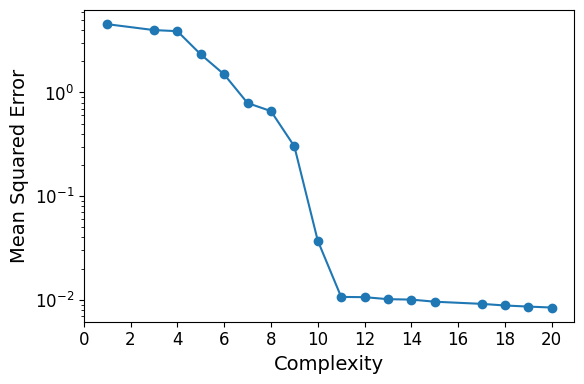

In [4]:
figure(figsize=(6, 4))

plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14

plt.plot(df["complexity"], df["loss"], "o-")

plt.ylabel("Mean Squared Error")
plt.xlabel("Complexity")
plt.yscale("log")

# plt.legend()
plt.xticks(np.arange(0, 22, step=2))

plt.tight_layout()

plt.savefig("figures/FH_MSE_Complex.jpg", dpi=600)

# Define helper functions

In [5]:
def fix_floats(expr, precision=1):
    """Turn floats in sympy expressions into 0 or rationals. The prototype for this code was generated by Google Gemini."""
    replacement_map = {}

    for n in expr.atoms(sp.Float):
        if abs(n) < 1e-4:
            replacement_map[n] = sp.Integer(0)
        else:
            replacement_map[n] = sp.Rational(1, round(1.0 / n, 0))

    return expr.xreplace(replacement_map)


def set_ground_truth():
    """Define the Flory Huggins spinodal as the ground truth."""

    x0, x1 = sp.symbols("x0 x1")
    expr = (1 / 2) / (1 - x0) + (1 / 2) / (x0 * x1)

    return expr


def compare(ex, gt):
    """Compare an expression to the ground truth."""

    simp = sp.simplify(ex)
    exround = fix_floats(simp)
    diff = sp.simplify(exround - gt)

    if diff == 0:
        return True

    return False


def find_best_eq(df, lim):
    """Find the best equation from a pandas DataFrame and determine if it matches the ground truth."""

    df = df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    score = df["score"].to_numpy()
    loss = df["loss"].to_numpy()

    mincrit = min(loss) * 1.5
    if mincrit < lim:
        mincrit = lim

    mask = loss < mincrit

    maxscore = max(score[mask])

    l = np.where(score == maxscore)[0][0]
    eq = df.iloc[l]["equation"]

    try:
        if compare(parse_expr(eq), set_ground_truth()):
            return True, eq, l
    except:
        print("warning")

    return False, eq, l


def check_eq(df, complexity=11):
    """Take the equation of a given complexity and determine if it matches the ground truth."""

    for j in range(len(df)):

        eq = df.iloc[j]["equation"]

        if df.iloc[j]["complexity"] == complexity:
            try:
                if compare(parse_expr(eq), set_ground_truth()):
                    return True, eq, j
                else:
                    return False, eq, -1
            except:
                print("warning")

    return False, eq, -1

# Error in y

## Compare the equation with complexity of 11

In [6]:
errorlist = ["100.0", "3.0", "2.0", "1.0", "-0.0"]

results = np.zeros((7, len(errorlist)))
x0, x1 = symbols("x0 x1")

for e, error in enumerate(errorlist):

    for k, p in enumerate(np.array([200, 100, 50, 20, 10, 5, 3])):

        count = 0
        for i in range(20):

            df = pd.read_csv(
                "symreg/dyp" + str(p) + "i" + str(i) + "e" + error + ".csv"
            )

            match, eq, l = check_eq(df)

            count += int(match)

        results[k, e] = count / 20.0

df = pd.DataFrame(
    np.hstack([np.array([200, 100, 50, 20, 10, 5, 3]).reshape(-1, 1), results]),
    columns=["p", np.inf, -3, -2, -1, 0],
)

df.to_csv("results/dy_eq11.csv", index=False)

df

,p,inf,-3,-2,-1,0
0,200.0,1.00,1.00,1.0,1.00,1.00
1,100.0,1.00,1.00,1.0,1.00,0.75
2,50.0,1.00,1.00,1.0,1.00,0.45
3,20.0,1.00,1.00,1.0,0.95,0.05
4,10.0,0.95,1.00,1.0,0.70,0.00
5,5.0,0.70,0.65,0.3,0.00,0.00
6,3.0,0.00,0.00,0.0,0.00,0.00


## Find the equation using the 'best' formalism from pysr modified to account for error

In [7]:
errorlist = ["100.0", "3.0", "2.0", "1.0", "-0.0"]

results = np.zeros((7, len(errorlist)))
x0, x1 = symbols("x0 x1")

for e, error in enumerate(errorlist):

    if error == "100.0":
        lim = 1e-4
    else:
        lim = 10.0 ** (-1 * int(float(error)))

    for k, p in enumerate(np.array([200, 100, 50, 20, 10, 5, 3])):

        count = 0
        for i in range(20):

            df = pd.read_csv(
                "symreg/dyp" + str(p) + "i" + str(i) + "e" + error + ".csv"
            )

            match, eq, l = find_best_eq(df, lim)
            # print(match, eq)

            count += int(match)

        results[k, e] = count / 20.0

df = pd.DataFrame(
    np.hstack([np.array([200, 100, 50, 20, 10, 5, 3]).reshape(-1, 1), results]),
    columns=[np.nan, np.inf, -3, -2, -1, 0],
)

df.to_csv("results/dy_best.csv", index=False)

df

,NaN,inf,-3.0,-2.0,-1.0,0.0
0,200.0,1.00,1.00,1.00,0.35,0.15
1,100.0,1.00,1.00,1.00,0.65,0.10
2,50.0,1.00,1.00,1.00,0.40,0.15
3,20.0,1.00,1.00,1.00,0.35,0.00
4,10.0,0.90,1.00,1.00,0.35,0.00
5,5.0,0.65,0.55,0.05,0.00,0.00
6,3.0,0.00,0.00,0.00,0.00,0.00


# Error in x

## Compare the equation with complexity of 11

In [8]:
errorlist = ["100.0", "4.0", "3.0", "2.0", "1.0", "-0.0"]

results = np.zeros((7, len(errorlist)))
x0, x1 = symbols("x0 x1")

for e, error in enumerate(errorlist):

    for k, p in enumerate(np.array([200, 100, 50, 20, 10, 5, 3])):

        count = 0
        for i in range(20):

            if error == "100.0":
                df = pd.read_csv(
                    "symreg/dyp" + str(p) + "i" + str(i) + "e" + error + ".csv"
                )
            else:
                df = pd.read_csv(
                    "symreg/dxp" + str(p) + "i" + str(i) + "e" + error + ".csv"
                )

            match, eq, l = check_eq(df)

            count += int(match)

        results[k, e] = count / 20.0

df = pd.DataFrame(
    np.hstack([np.array([200, 100, 50, 20, 10, 5, 3]).reshape(-1, 1), results]),
    columns=["p", np.inf, -4, -3, -2, -1, 0],
)

df.to_csv("results/dx_eq11.csv", index=False)

df

,p,inf,-4,-3,-2,-1,0
0,200.0,1.00,1.0,1.00,0.35,0.0,0.0
1,100.0,1.00,1.0,1.00,0.50,0.0,0.0
2,50.0,1.00,1.0,1.00,0.50,0.0,0.0
3,20.0,1.00,1.0,0.85,0.55,0.0,0.0
4,10.0,0.95,1.0,0.95,0.55,0.0,0.0
5,5.0,0.70,0.5,0.40,0.10,0.0,0.0
6,3.0,0.00,0.0,0.00,0.00,0.0,0.0


## Find the equation using the 'best' formalism from pysr modified to account for error

In [9]:
errorlist = ["100.0", "4.0", "3.0", "2.0", "1.0", "-0.0"]

results = np.zeros((7, len(errorlist)))
x0, x1 = symbols("x0 x1")

for e, error in enumerate(errorlist):

    if error == "100.0":
        lim = 1e-4
    else:
        lim = 10.0 ** (
            -1 * int(float(error)) + 1
        )  # add a cushion since x error does not translate to y error

    for k, p in enumerate(np.array([200, 100, 50, 20, 10, 5, 3])):

        count = 0
        for i in range(20):

            if error == "100.0":
                df = pd.read_csv(
                    "symreg/dyp" + str(p) + "i" + str(i) + "e" + error + ".csv"
                )
            else:
                df = pd.read_csv(
                    "symreg/dxp" + str(p) + "i" + str(i) + "e" + error + ".csv"
                )

            match, eq, l = find_best_eq(df, lim)
            # print(match, eq)

            count += int(match)

        results[k, e] = count / 20.0

df = pd.DataFrame(
    np.hstack([np.array([200, 100, 50, 20, 10, 5, 3]).reshape(-1, 1), results]),
    columns=[np.nan, np.inf, -4, -3, -2, -1, 0],
)

df.to_csv("results/dx_best.csv", index=False)

df

,NaN,inf,-4.0,-3.0,-2.0,-1.0,0.0
0,200.0,1.00,1.0,0.40,0.10,0.0,0.0
1,100.0,1.00,1.0,0.65,0.10,0.0,0.0
2,50.0,1.00,1.0,0.85,0.10,0.0,0.0
3,20.0,1.00,1.0,0.85,0.20,0.0,0.0
4,10.0,0.90,1.0,0.85,0.15,0.0,0.0
5,5.0,0.65,0.3,0.15,0.00,0.0,0.0
6,3.0,0.00,0.0,0.00,0.00,0.0,0.0
